In [1]:
import scanpy as sc
import pandas as pd

# Paths to your files
control_path = r"C:\Users\s244148\Downloads\GSE204844_RAW\GSM6198712_Control.counts.tsv.gz"
case_path = r"C:\Users\s244148\Downloads\GSE204844_RAW\GSM6198711_Case.counts.tsv.gz"

# Load expression matrices
control_df = pd.read_csv(control_path, sep="\t", index_col=0)
case_df = pd.read_csv(case_path, sep="\t", index_col=0)

# Transpose so genes are columns (Scanpy expects cells x genes)
control_df = control_df.T
case_df = case_df.T

# Create AnnData objects
adata_control = sc.AnnData(control_df)
adata_control.obs["condition"] = "Control"

adata_case = sc.AnnData(case_df)
adata_case.obs["condition"] = "Case"

# Concatenate into one AnnData
adata = adata_control.concatenate(adata_case, batch_key="sample", batch_categories=["Control", "Case"])

adata


C:\Users\s244148\AppData\Local\Temp\ipykernel_6196\8915887.py:24: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_control.concatenate(adata_case, batch_key="sample", batch_categories=["Control", "Case"])


AnnData object with n_obs × n_vars = 9965 × 15707
    obs: 'condition', 'sample'

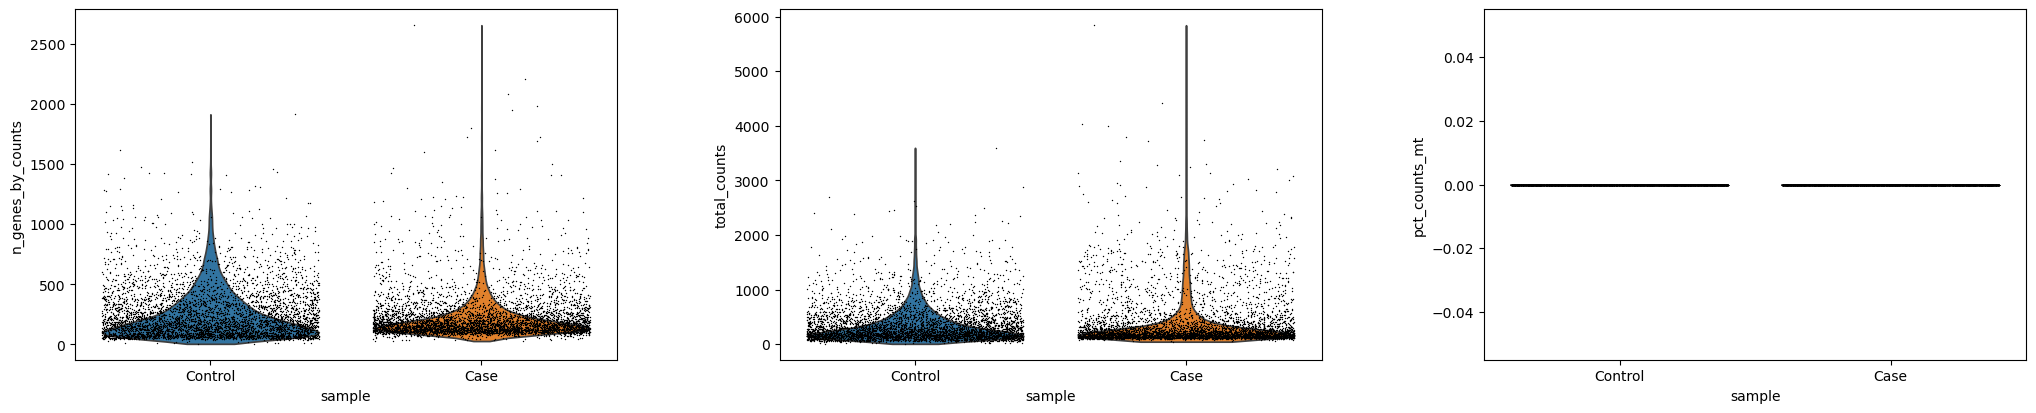

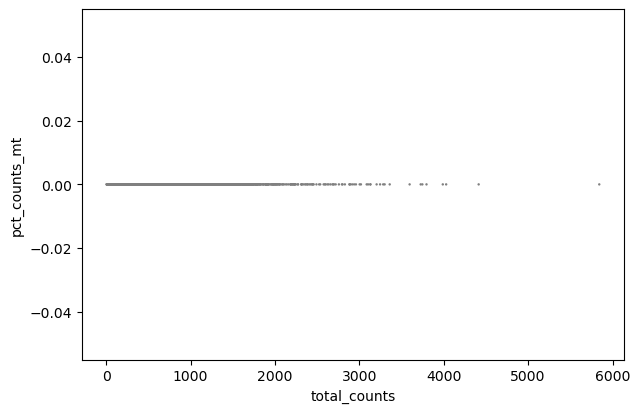

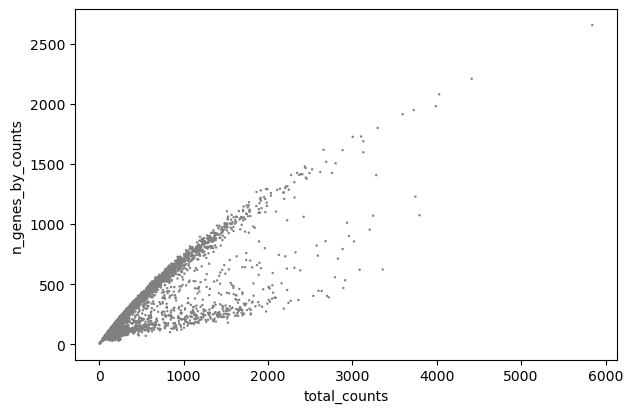

View of AnnData object with n_obs × n_vars = 3986 × 15707
    obs: 'condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sample_colors'

In [2]:
# Identify mitochondrial genes (mouse mt genes start with 'mt-')
adata.var["mt"] = adata.var_names.str.startswith("mt-")

# Compute QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# Visualize distributions before filtering
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, groupby='sample')

# Scatter plots to help visualize cutoffs
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

# Apply filters based on paper
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.n_genes_by_counts < 5000, :]
adata = adata[adata.obs.pct_counts_mt < 20, :]

adata


In [3]:
# Normalize each cell to have total counts = 1e4 (library size normalization)
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(adata)

# Store raw counts before further processing
adata.raw = adata


C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


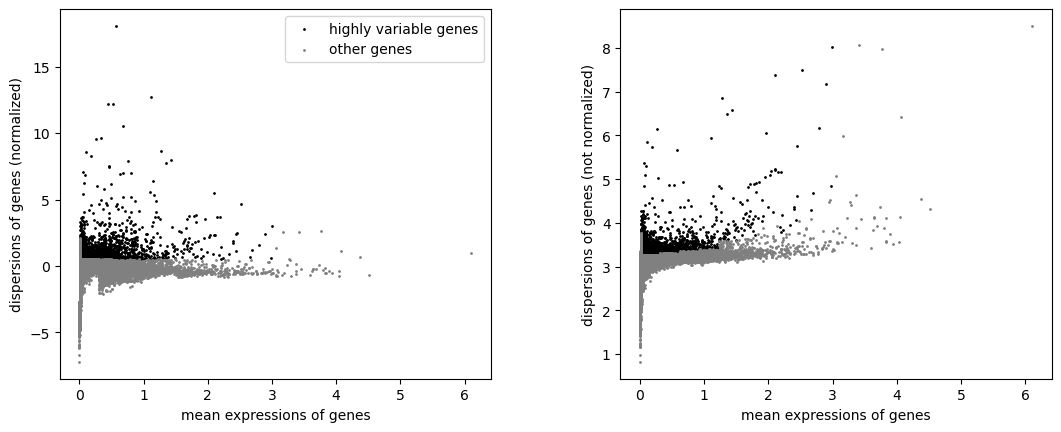

In [4]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Plot HVGs
sc.pl.highly_variable_genes(adata)

# Keep only HVGs
adata = adata[:, adata.var.highly_variable]


C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


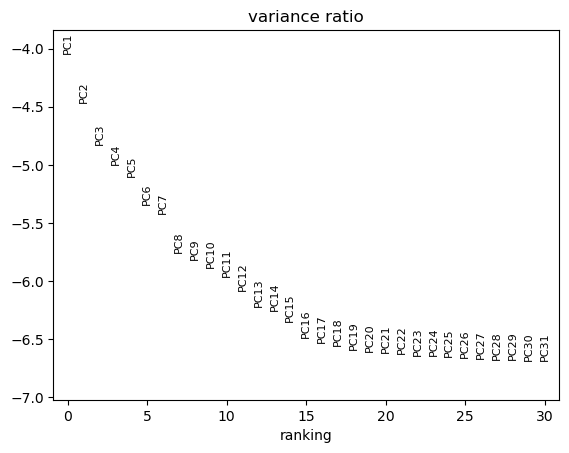

In [5]:
# Scale each gene to unit variance, clip extreme values to avoid outliers dominating
sc.pp.scale(adata, max_value=10)

# Run PCA
sc.tl.pca(adata, svd_solver='arpack')

# Plot variance ratio to see how many PCs to use
sc.pl.pca_variance_ratio(adata, log=True)


C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\s244148\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\s244148\AppData\Local\anaconda3\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, 

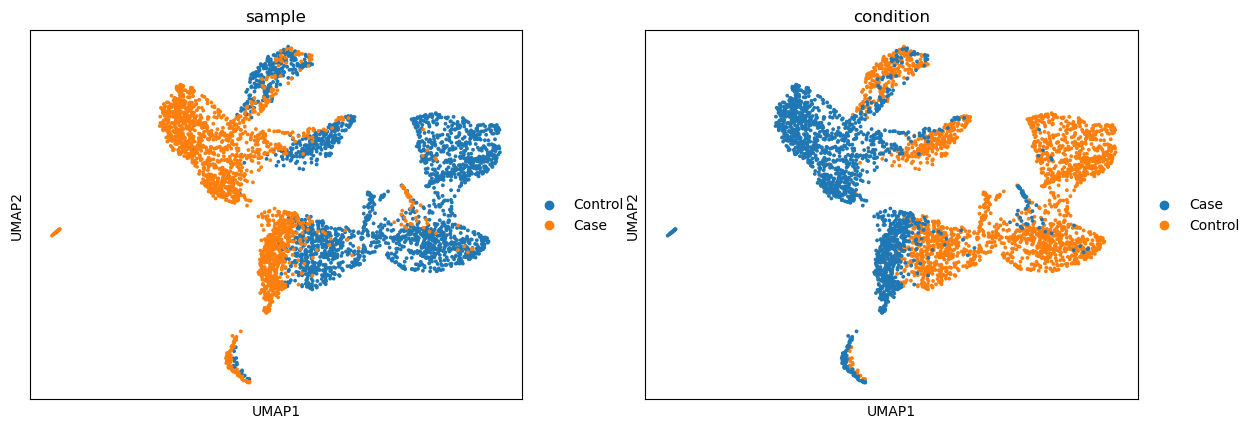

In [6]:
# Build the nearest-neighbors graph using top 10 PCs (as in the paper)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=10)

# UMAP embedding
sc.tl.umap(adata)
sc.pl.umap(adata, color=['sample', 'condition'])


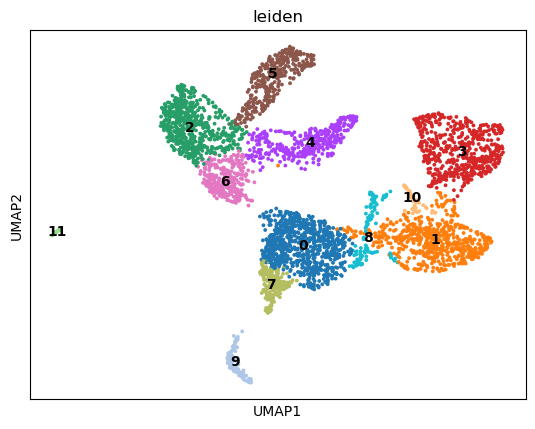

In [9]:
# Cluster using Leiden (graph-based, like Seurat's Louvain method)
sc.tl.leiden(adata, resolution=0.5)  # Try resolution=0.3–1.0 if you want more/fewer clusters

# Visualize clusters on UMAP
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')


In [10]:
# Broad panel of markers across known pancreas cell types
marker_genes = [
    "Amy2a5", "Cpa1",        # Acinar
    "Krt19", "Sox9",         # Ductal
    "Ins1", "Ins2", "Pdx1",  # Beta
    "Gcg",                   # Alpha
    "Sst",                   # Delta
    "Ppy",                   # PP
    "Cd68", "Adgre1",        # Macrophage
    "Cd3d", "Cd3e",          # T cells
    "Col1a1", "Col3a1", "Dcn", # Fibroblasts
    "Pecam1", "Cdh5"         # Endothelial
]

sc.pl.umap(adata, color=marker_genes, cmap="magma", ncols=4)


KeyError: 'Amy2a5'

<Figure size 2911.2x2400 with 0 Axes>

In [11]:
print(adata.var_names[:20])  # see the first 20 genes


Index(['ENSMUSG00000000031', 'ENSMUSG00000000056', 'ENSMUSG00000000085',
       'ENSMUSG00000000088', 'ENSMUSG00000000120', 'ENSMUSG00000000127',
       'ENSMUSG00000000148', 'ENSMUSG00000000157', 'ENSMUSG00000000204',
       'ENSMUSG00000000244', 'ENSMUSG00000000276', 'ENSMUSG00000000318',
       'ENSMUSG00000000384', 'ENSMUSG00000000399', 'ENSMUSG00000000409',
       'ENSMUSG00000000440', 'ENSMUSG00000000489', 'ENSMUSG00000000561',
       'ENSMUSG00000000579', 'ENSMUSG00000000594'],
      dtype='object', name='gene')


In [12]:
# Check if the gene exists at all (case-insensitive match)
any(adata.var_names.str.upper() == "AMY2A5")


False

In [13]:
# Search for similar gene names
[gene for gene in adata.var_names if "amy" in gene.lower()]


[]

In [19]:
import mygene

# Initialize the query object
mg = mygene.MyGeneInfo()

# Query Ensembl IDs to get gene symbols (batch mode)
ensembl_ids = adata.var_names.tolist()
query_results = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='mouse')

# Convert to DataFrame
gene_map = pd.DataFrame(query_results).set_index('query')

# Add gene symbols to adata.var (from previous step)
adata.var['gene_symbol'] = gene_map['symbol']

# (NEW) Save current Ensembl IDs for safety
adata.var['ensembl_id'] = adata.var_names

# Ensure no duplicated symbols cause problems downstream
adata.var_names_make_unique()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
37 input query terms found no hit:	['ENSMUSG00000024952', 'ENSMUSG00000046993', 'ENSMUSG00000048191', 'ENSMUSG00000065145', 'ENSMUSG000


In [15]:
!pip install mygene



   ---------------------------------------- 0/2 [biothings-client]
   ---------------------------------------- 2/2 [mygene]



In [21]:
marker_genes = ["Amy2a5", "Sox9", "Ins1", "Gcg", "Sst", "Pecam1", "Col1a1", "Cd68", "Cd3d"]
sc.pl.umap(adata, color=marker_genes, cmap="magma", ncols=4)


KeyError: 'Amy2a5'

<Figure size 2911.2x1440 with 0 Axes>

In [38]:
# Define your intended marker genes
marker_genes = ["Amy2a5", "Sox9", "Ins1", "Gcg", "Sst", "Pecam1", "Col1a1", "Cd68", "Cd3d", "Lpar5", "Timp1", "Mmp2"]

# Check which ones are found in the dataset by matching gene_symbol
valid_markers = [gene for gene in marker_genes if gene in adata.var['gene_symbol'].values]

print("Valid markers found in data:", valid_markers)


Valid markers found in data: ['Ins1', 'Sst', 'Pecam1', 'Col1a1', 'Cd68', 'Cd3d', 'Mmp2']


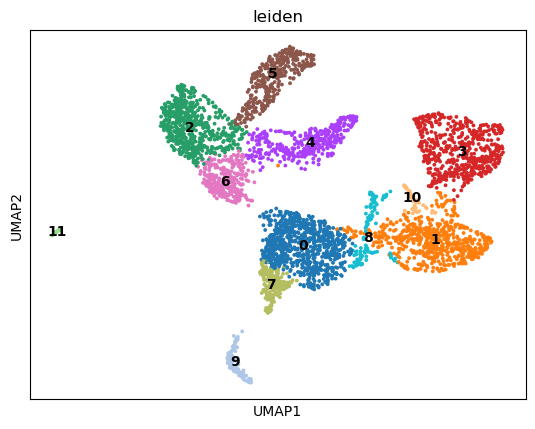

In [22]:
sc.pl.umap(adata, color="leiden", legend_loc="on data")


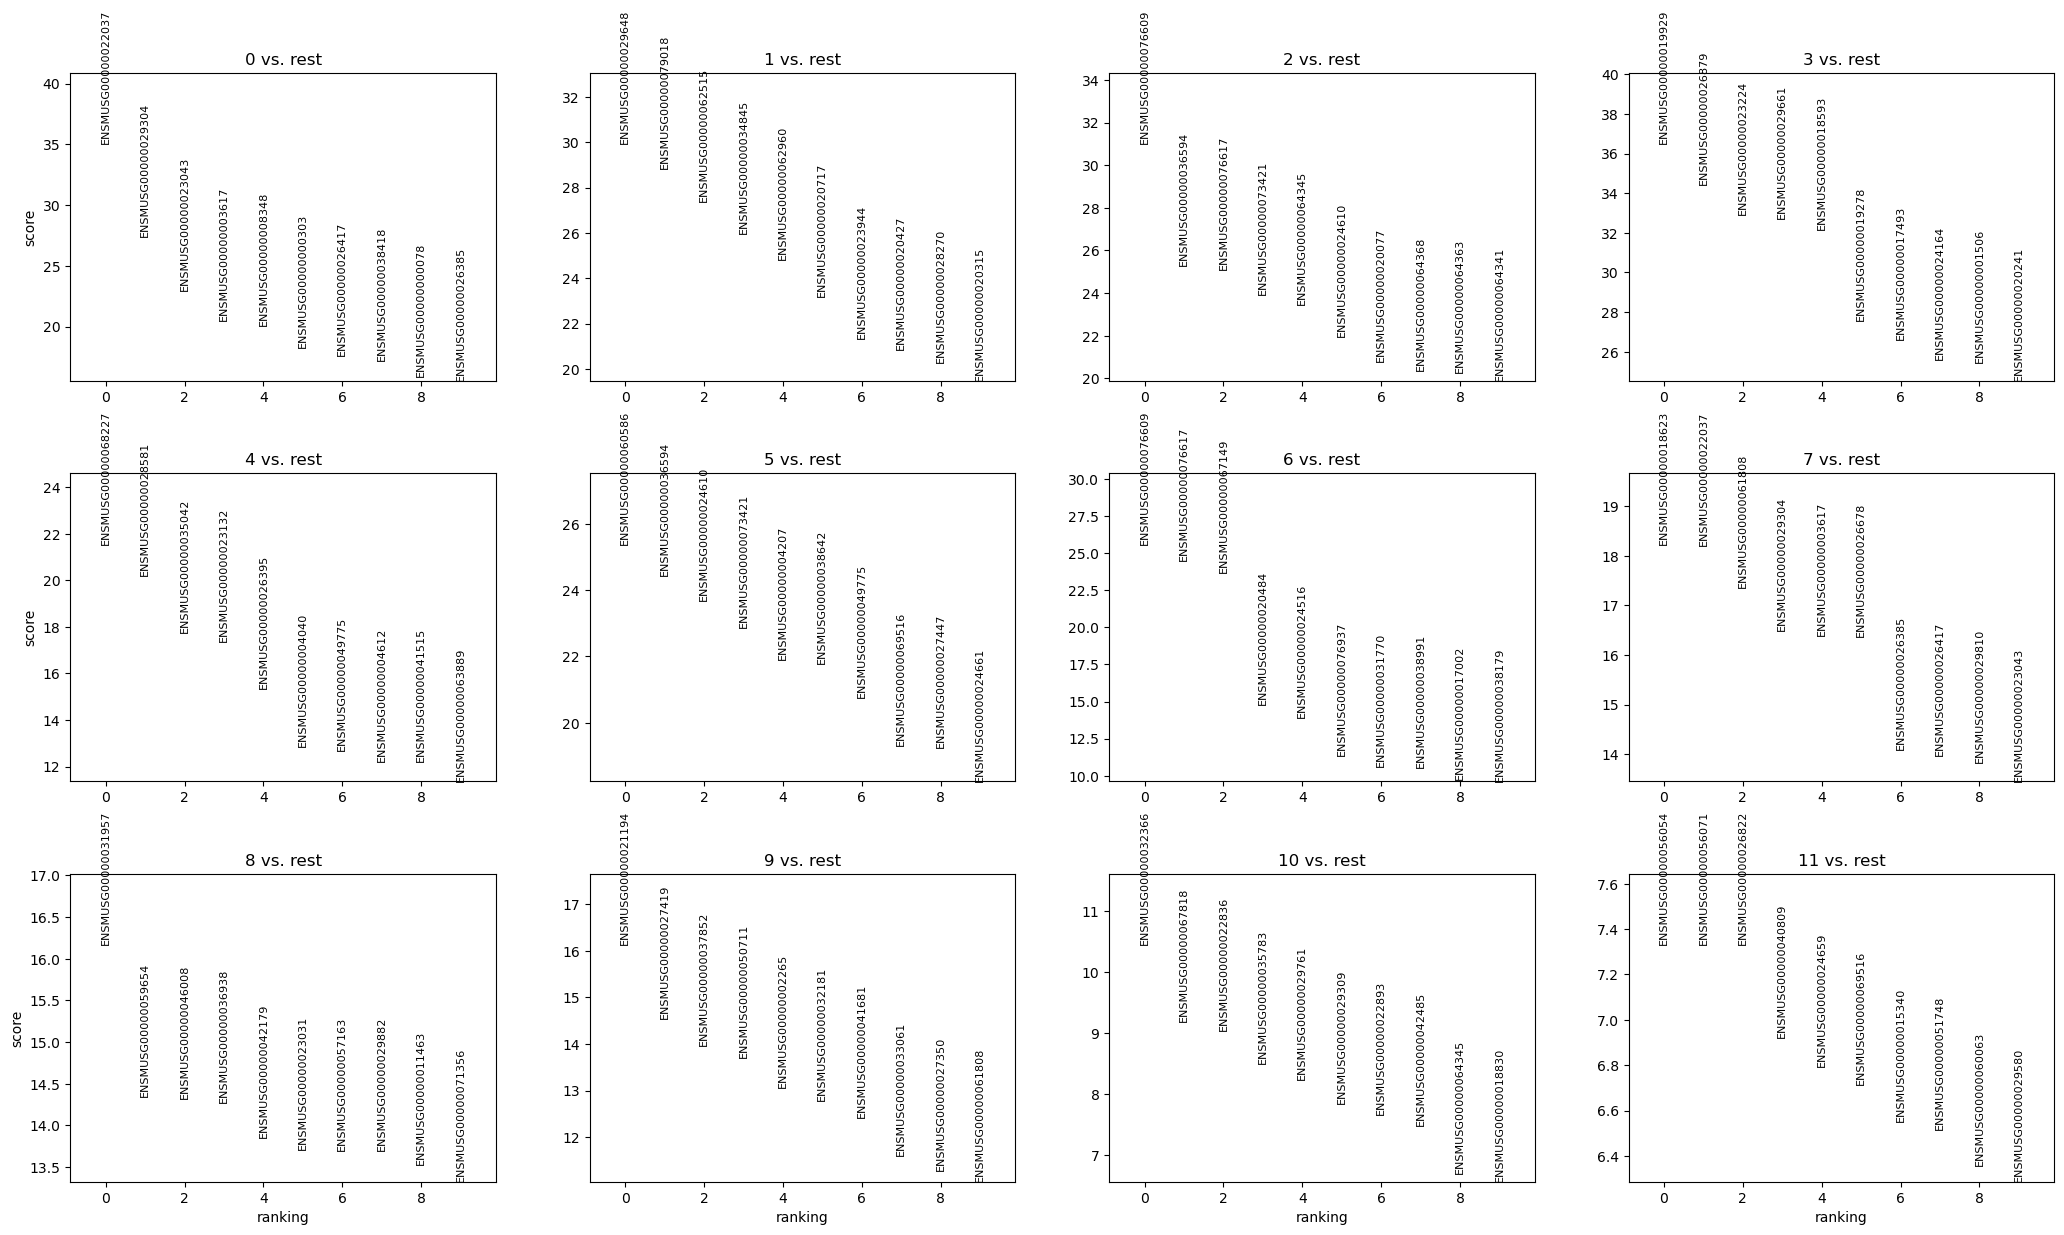

In [23]:
# Perform differential expression: one-vs-all using Wilcoxon test
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', n_genes=50)

# Plot top markers per cluster
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)


In [25]:
"LPAR5" in adata.var['gene_symbol'].values


False

In [26]:
[gene for gene in adata.var['gene_symbol'].dropna().values if "lpar5" in gene.lower()]


[]

In [27]:
[gene for gene in adata.var['gene_symbol'].dropna().values if "gpr" in gene.lower()]


['Gpr132',
 'Gpr137b',
 'Gpr35',
 'Gpr141b',
 'Gpr137c',
 'Gpr55',
 'Gpr171',
 'Gpr18',
 'Gpr183',
 'Gpr141',
 'Gpr174',
 'Gpr137b-ps']

In [28]:
"ENSMUSG00000030503" in adata.var_names  # Lpar5's Ensembl ID in mouse


False

In [29]:
control_df = pd.read_csv(control_path, sep="\t", index_col=0).T
case_df = pd.read_csv(case_path, sep="\t", index_col=0).T


In [30]:
# Reload raw data again
import pandas as pd

control_path = r"C:\Users\s244148\Downloads\GSE204844_RAW\GSM6198712_Control.counts.tsv.gz"
case_path = r"C:\Users\s244148\Downloads\GSE204844_RAW\GSM6198711_Case.counts.tsv.gz"

control_raw = pd.read_csv(control_path, sep="\t", index_col=0).T
case_raw = pd.read_csv(case_path, sep="\t", index_col=0).T


In [40]:
# Check for gene names in raw (rows are genes after transpose)
[gene for gene in control_raw.columns if "Lpar5" in gene.lower() or "Gpr92" in gene.lower()]


[]

In [33]:
# Search in raw data for LPAR5's Ensembl ID (mouse)
"ENSMUSG00000030503" in control_raw.columns, "ENSMUSG00000030503" in case_raw.columns


(False, False)

In [34]:
# If found, print some stats
if "ENSMUSG00000030503" in control_raw.columns:
    print("Control LPAR5 expression summary:")
    print(control_raw["ENSMUSG00000030503"].describe())

if "ENSMUSG00000030503" in case_raw.columns:
    print("Case LPAR5 expression summary:")
    print(case_raw["ENSMUSG00000030503"].describe())
